<a href="https://colab.research.google.com/github/natbates/Speaker-Identification-Machine-learning-model/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speaker identification with machine learning

## Set Up Environment

Import essential machine learning libraries such as pandas, numpy, and scikit-learn. If specific libraries are not mentioned, general-purpose ones will be imported.


In [10]:
import pandas as pd
import numpy as np
import sklearn
import os
import zipfile
import librosa

print("Libraries imported successfully.")

Libraries imported successfully.


## Extract Data from Zip

Locate and extract data from a specified zip file in storage. This step will involve identifying the zip file and extracting its contents to a suitable directory.


In [9]:
file_name = 'LibriSpeech.zip'
if os.path.exists(file_name):
    size = os.path.getsize(file_name)
    print(f"File '{file_name}' size: {size} bytes")
    if size == 0:
        print("The file is empty.")
else:
    print(f"File '{file_name}' does not exist.")

File 'LibriSpeech.zip' size: 338300057 bytes


In [11]:
zip_file_path = 'LibriSpeech.zip'

extract_dir = 'extracted_data'

os.makedirs(extract_dir, exist_ok=True)

try:
    # Open the zip file in read mode and extract all its contents
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Data extracted to '{extract_dir}' successfully from '{zip_file_path}'.")
except FileNotFoundError:
    print(f"Error: The specified zip file '{zip_file_path}' was not found.")
except zipfile.BadZipFile:
    print(f"Error: The file '{zip_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred during extraction: {e}")

Data extracted to 'extracted_data' successfully from 'LibriSpeech.zip'.


## Data Preprocessing

Parse the speaker metadata and map it to the corresponding audio file paths found in the extracted directory.


In [26]:
speakers_txt_path = 'extracted_data/LibriSpeech/SPEAKERS.TXT'

speaker_df = pd.read_csv(
    speakers_txt_path,
    sep='|',
    comment=';',           # ignore comment lines
    header=None,
    engine='python',
    on_bad_lines='skip'    # skip malformed rows safely
)

# Keep only first 5 columns (ignore extra splits)
speaker_df = speaker_df.iloc[:, :5]

# Assign proper column names
speaker_df.columns = ['ID', 'SEX', 'SUBSET', 'MINUTES', 'NAME']

# Clean whitespace
speaker_df = speaker_df.apply(lambda x: x.astype(str).str.strip())

print(f"Loaded {len(speaker_df)} speaker metadata entries.")
print(speaker_df.head())
print(speaker_df.columns)

Loaded 2483 speaker metadata entries.
   ID SEX           SUBSET MINUTES              NAME
0  14   F  train-clean-360   25.03   Kristin LeMoine
1  16   F  train-clean-360   25.11    Alys AtteWater
2  17   M  train-clean-360   25.04    Gord Mackenzie
3  19   F  train-clean-100   25.19  Kara Shallenberg
4  20   F  train-other-500   30.07            Gesine
Index(['ID', 'SEX', 'SUBSET', 'MINUTES', 'NAME'], dtype='object')


## Stratified Data Split

Perform a stratified train/test split on the mapped DataFrame using speaker IDs.


**Reasoning**:
I will perform a stratified train/test split on the master_df using the speaker ID to ensure that both sets represent the same speakers, first filtering out speakers with only one sample to satisfy stratification requirements.



In [27]:
from sklearn.model_selection import train_test_split

speaker_counts = master_df['ID'].value_counts()
speakers_to_keep = speaker_counts[speaker_counts > 1].index
filtered_df = master_df[master_df['ID'].isin(speakers_to_keep)].copy()

print(f"Original records: {len(master_df)}")
print(f"Records after filtering single-sample speakers: {len(filtered_df)}")

# Perform stratified split (80% train, 20% test)
train_df, test_df = train_test_split(
    filtered_df,
    test_size=0.2,
    random_state=42,
    stratify=filtered_df['ID']
)

print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")
print(f"Number of unique speakers in train: {train_df['ID'].nunique()}")
print(f"Number of unique speakers in test: {test_df['ID'].nunique()}")

Original records: 2703
Records after filtering single-sample speakers: 2703
Training set shape: (2162, 6)
Testing set shape: (541, 6)
Number of unique speakers in train: 40
Number of unique speakers in test: 40


## Feature Extraction Pipeline

extract MFCC features from the FLAC audio files.


**Reasoning**:
I will check for the availability of librosa, install it if necessary, and then define the MFCC extraction function to test it on a sample of the training data.



In [31]:

def extract_mfcc(file_path, n_mfcc=39, duration=3.0):
    """
    Extracts mean MFCCs from a FLAC audio file.
    """
    try:
        # Load audio file (first 3 seconds)
        y, sr = librosa.load(file_path, duration=duration)

        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # Compute the mean across the time axis (axis=1)
        mfccs_processed = np.mean(mfccs, axis=1)

        return mfccs_processed
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Test on a small sample of train_df
sample_test = train_df.head(5).copy()
sample_test['mfcc'] = sample_test['file_path'].apply(lambda x: extract_mfcc(x))

print("Sample feature extraction results:")
print(sample_test[['ID', 'mfcc']])
print(f"Feature vector shape: {sample_test['mfcc'].iloc[0].shape}")

Sample feature extraction results:
     ID                                               mfcc
0  1993  [-486.7384, 85.64357, -27.340115, 61.103905, -...
1   777  [-392.31003, 135.6235, -25.72609, 57.297718, -...
2  2035  [-343.35208, 98.14776, -35.972763, 39.95665, -...
3  1272  [-324.6599, 99.82278, 1.0247732, 48.44582, -14...
4  6313  [-335.7487, 97.0258, -86.34361, 23.950396, -30...
Feature vector shape: (39,)


## Prepare Training Data

Extract MFCC features for all samples, encode labels, and prepare data for CNN input.


In [29]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Apply extract_mfcc to all file paths
print("Extracting features for training set...")
train_df['features'] = train_df['file_path'].apply(lambda x: extract_mfcc(x))
print("Extracting features for testing set...")
test_df['features'] = test_df['file_path'].apply(lambda x: extract_mfcc(x))

# 2. Filter out failures
train_df = train_df.dropna(subset=['features']).reset_index(drop=True)
test_df = test_df.dropna(subset=['features']).reset_index(drop=True)

# 3. Label Encoding for Speaker IDs
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['ID'])
test_df['label'] = le.transform(test_df['ID'])
num_classes = len(le.classes_)

# 4. Convert to NumPy arrays and reshape for CNN (N, Features, Channels)
X_train = np.stack(train_df['features'].values)
X_test = np.stack(test_df['features'].values)

# Reshape to (Samples, 39, 1) for 1D CNN compatibility
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

y_train = train_df['label'].values
y_test = test_df['label'].values

# 5. Verification
print(f"\nFinal Shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Number of unique classes: {num_classes}")

Extracting features for training set...
Extracting features for testing set...

Final Shapes:
X_train shape: (2162, 39, 1)
y_train shape: (2162,)
X_test shape: (541, 39, 1)
y_test shape: (541,)
Number of unique classes: 40


## Define CNN Architecture

Construct a 1D Convolutional Neural Network (CNN) using Keras/TensorFlow for speaker classification based on MFCC features.


In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Define the 1D CNN model architecture
model = Sequential([
    # First convolutional block
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(39, 1)),
    MaxPooling1D(pool_size=2),

    # Second convolutional block
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output layer
    Dense(num_classes, activation='softmax')
])

# Compile the model (optional at this step, but good for summary context)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model architecture summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 37, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,320 (630.16 KB)

 Trainable params: 161,320 (630.16 KB)

 Non-trainable params: 0 (0.00 B)

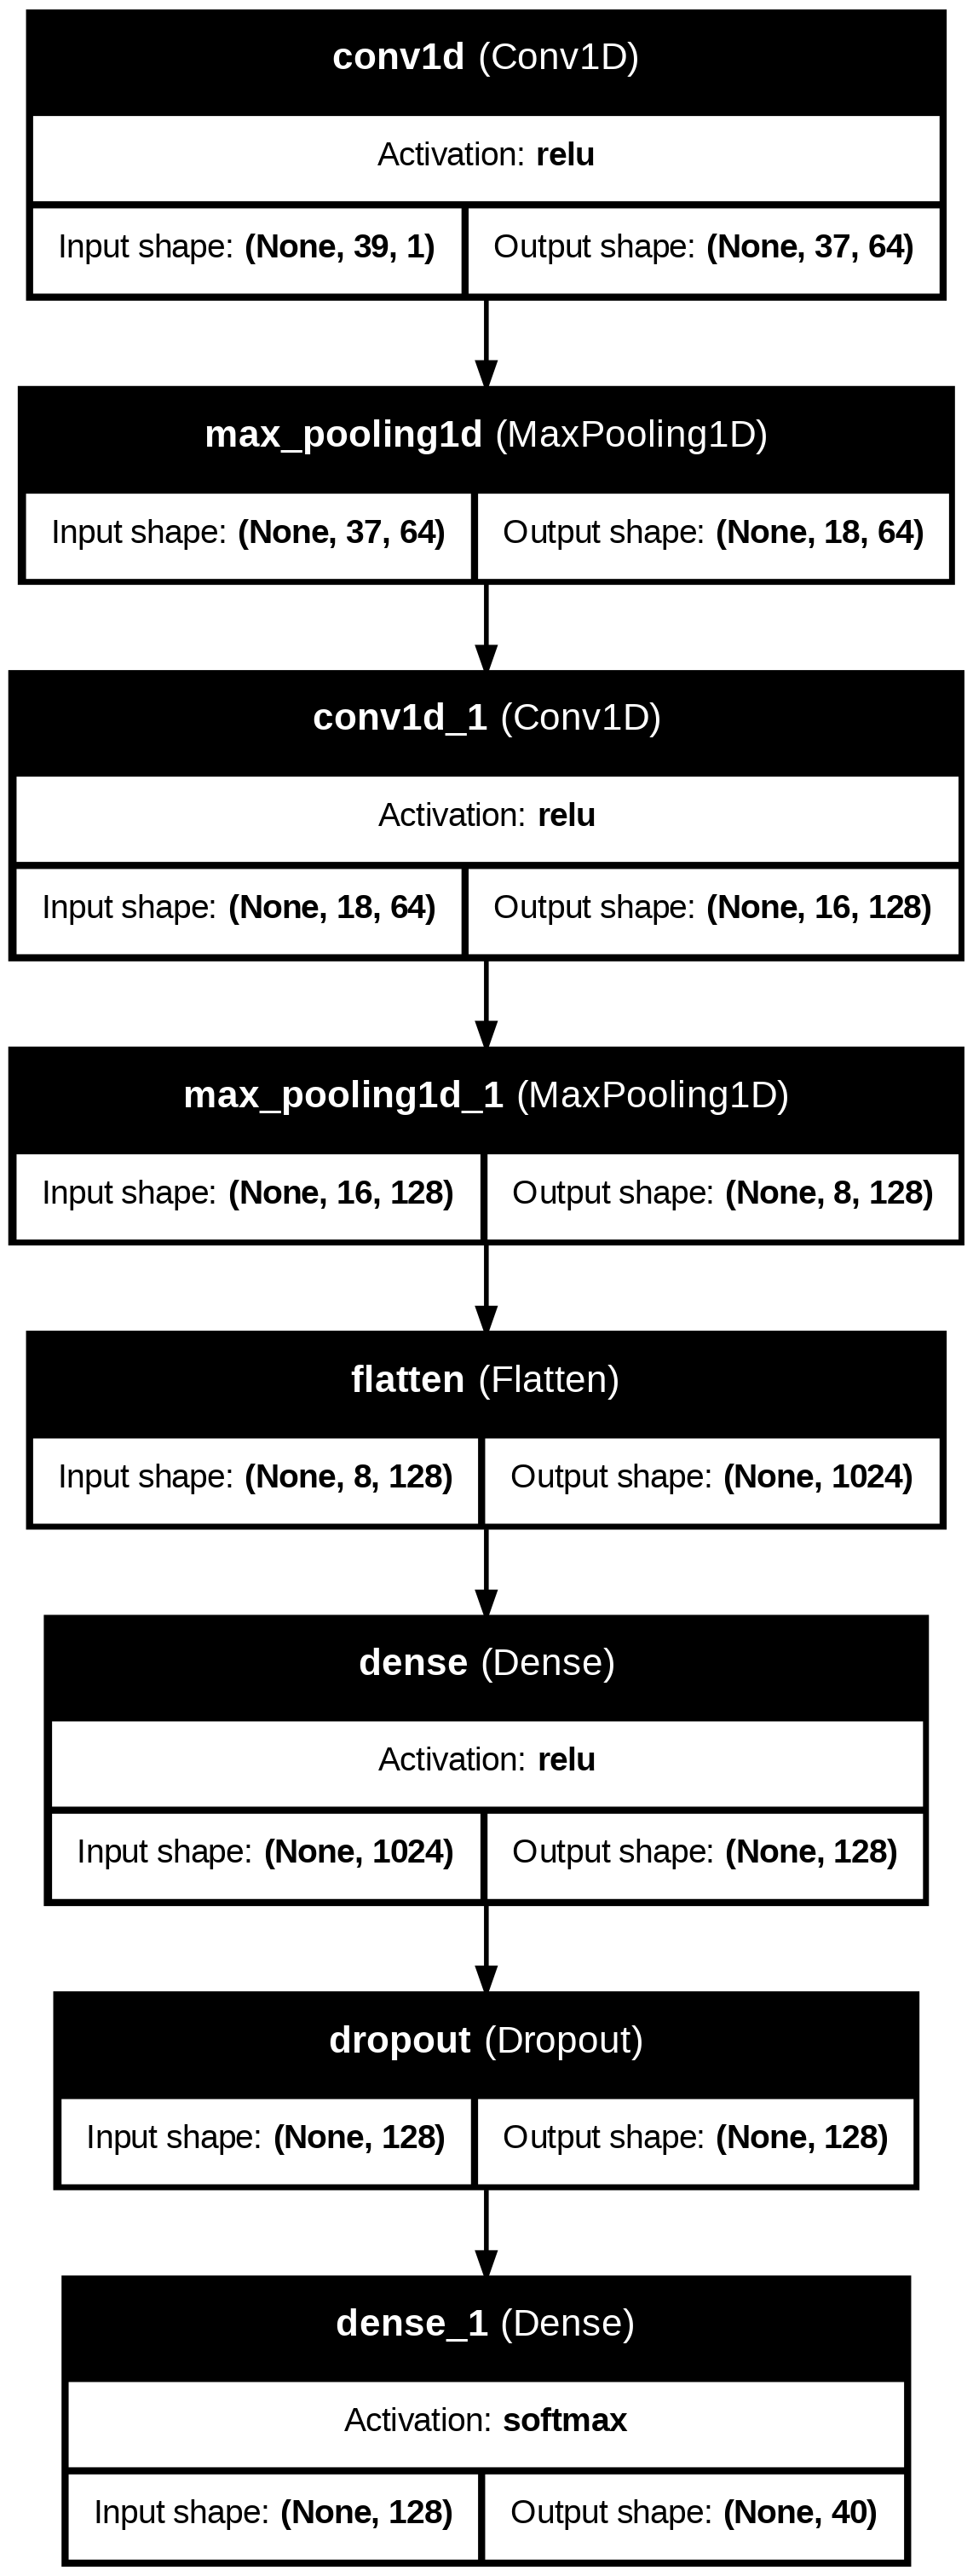

In [34]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

# Generate the model plot
plot_path = 'model_architecture.png'
plot_model(
    model,
    to_file=plot_path,
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True
)

# Display the image in the notebook
display(Image(plot_path))

## Train and Evaluate Model

Train the CNN model on the extracted MFCC features and evaluate its performance on the test set.


In [54]:
import random
import IPython.display as ipd

# 1. Select a random sample from test_df
idx = random.randint(0, len(test_df) - 1)
sample_row = test_df.iloc[idx]

# 2. Get the corresponding feature vector and reshape for prediction
# X_test[idx] is already reshaped to (39, 1)
sample_features = X_test[idx].reshape(1, 39, 1)

# 3. Make prediction
prediction_probs = model.predict(sample_features, verbose=0)
predicted_label_idx = np.argmax(prediction_probs)
predicted_speaker = le.inverse_transform([predicted_label_idx])[0]

# 4. Display results
print(f"--- Live Demonstration ---")
print(f"File Path: {sample_row['file_path']}")
print(f"True Speaker ID: {sample_row['ID']}")
print(f"Model Predicted Speaker ID: {predicted_speaker}")

if str(sample_row['ID']) == str(predicted_speaker):
    print("✅ Prediction matches!")
else:
    print("❌ Prediction mismatch.")

# 5. Play the audio
ipd.display(ipd.Audio(sample_row['file_path']))

--- Live Demonstration ---
File Path: extracted_data/LibriSpeech/dev-clean/2078/142845/2078-142845-0039.flac
True Speaker ID: 2078
Model Predicted Speaker ID: 2078
✅ Prediction matches!


Starting model training...
Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0728 - loss: 4.6985 - val_accuracy: 0.4270 - val_loss: 2.3479
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3252 - loss: 2.4049 - val_accuracy: 0.7763 - val_loss: 1.1843
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5565 - loss: 1.5227 - val_accuracy: 0.9039 - val_loss: 0.5600
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6815 - loss: 1.0466 - val_accuracy: 0.9482 - val_loss: 0.3658
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7432 - loss: 0.8369 - val_accuracy: 0.9575 - val_loss: 0.2391
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7847 - loss: 0.6823 - val_accuracy: 0.9760 - val_loss: 0.1531
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8151 - loss: 0.6025 - val_accuracy: 0.9630 - val_loss: 0.1383
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8498 - loss: 0.4539 - 

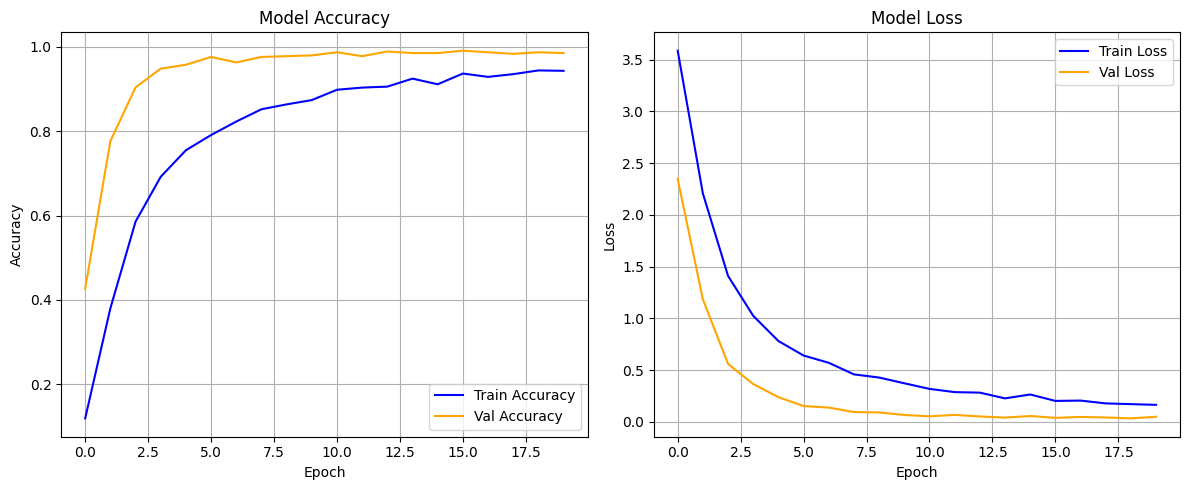


Final Test Accuracy: 0.9852
Final Test Loss: 0.0496


In [33]:
import matplotlib.pyplot as plt

# 1. Train the model
print("Starting model training...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# 2. Evaluate the model
print("\nEvaluating on test set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# 3. Plot training & validation metrics
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Print final test accuracy
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")